::: {.callout-note appearance="minimal" icon=false}
Language: **Python** (Jupyter notebook) - [R version](r.qmd)
:::

Ported from
[`09_statistics.ipynb`](https://github.com/USACE-RMC/Numerics-Python-Examples/blob/main/notebooks/09_statistics.ipynb)
in the USACE-RMC Numerics-Python-Examples repository (0BSD licensed). The upstream
notebook drives the C# `Numerics.dll` through pythonnet; this version uses
`corehydropy`, whose compiled core is a validated C++ port of the same library, so the
seeded results below reproduce the upstream outputs exactly. The R version of this
example uses the same core and prints the same numbers.

## What you'll learn

- Descriptive statistics and correlation with plain numpy and pandas.
- Empirical plotting positions, the port's public helper for frequency plots.
- Bootstrap confidence bands on a fitted quantile curve.
- Screening for low outliers with the Multiple Grubbs-Beck test.
- Box-Cox and Yeo-Johnson normalizing transformations.

## Setup

The upstream notebook loads the CoreCLR runtime, resolves `Numerics.dll`, and
converts every array with `convert_to_dotnet_array`. Here the only setup is
importing the packages.

In [1]:
import corehydropy as ch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Setup complete")

Setup complete


## Descriptive statistics

The upstream section drives the Numerics `Statistics` class. That class exists in
the port's core but is internal: the packages do not re-export what numpy, pandas,
and base R already do well. The estimators are the same, so the plain pandas
versions below reproduce the upstream summary table digit for digit:

- `Statistics.Variance` uses Bessel's correction (divide by $n-1$), like
  `Series.std()` and `Series.var()`.
- `Statistics.Skewness` is the bias-corrected Fisher skewness
  $G_1 = \frac{\sqrt{n(n-1)}}{n-2} \, m_3 / m_2^{3/2}$, exactly `Series.skew()`.
- `Statistics.Kurtosis` is the adjusted Fisher *excess* kurtosis, exactly
  `Series.kurt()` (the upstream table labels it "Kurtosis").
- `Statistics.Percentile` matches numpy's default linear interpolation
  (`quantile` type 7 in R).

The streamflow sample itself is seeded through the port, so it is bit-identical to
the upstream data. One naming gotcha carried over from C#: `LogNormal` is the
base-10 family (`LnNormal` is base e).

In [2]:
streamflow = np.asarray(ch.Distribution("LogNormal", [6.5, 0.8]).random(365, seed=42))
s = pd.Series(streamflow)

summary = pd.DataFrame({
    "Statistic": ["Mean", "Std Dev", "Variance", "Minimum", "Maximum",
                  "Skewness", "Excess kurtosis",
                  "5th %ile", "25th %ile", "75th %ile", "95th %ile"],
    "Value": [s.mean(), s.std(), s.var(), s.min(), s.max(), s.skew(), s.kurt(),
              *np.percentile(streamflow, [5, 25, 75, 95])],
})
print(summary.to_string(index=False))

      Statistic        Value
           Mean 1.397387e+07
        Std Dev 4.195469e+07
       Variance 1.760196e+15
        Minimum 7.526316e+03
        Maximum 5.909717e+08
       Skewness 8.697790e+00
Excess kurtosis 1.038059e+02
       5th %ile 1.270829e+05
      25th %ile 8.245169e+05
      75th %ile 8.827698e+06
      95th %ile 5.803155e+07


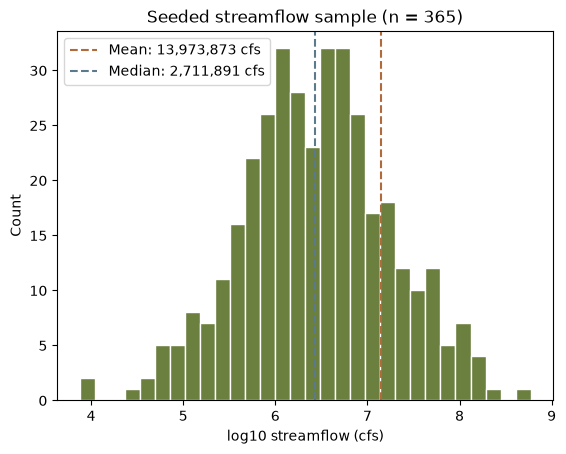

In [3]:
log_flow = np.log10(streamflow)
plt.hist(log_flow, bins=30, color="#6b7f3f", edgecolor="white")
plt.axvline(np.log10(s.mean()), color="#b06a3b", linestyle="--",
            label=f"Mean: {s.mean():,.0f} cfs")
plt.axvline(np.log10(s.median()), color="#5b7a8c", linestyle="--",
            label=f"Median: {s.median():,.0f} cfs")
plt.xlabel("log10 streamflow (cfs)")
plt.ylabel("Count")
plt.title("Seeded streamflow sample (n = 365)")
plt.legend()
plt.show()

## Plotting positions

The upstream notebook builds an empirical CDF by hand for its Kolmogorov-Smirnov
diagnostic. The port exposes `plotting_positions`, the standard family of
empirical non-exceedance probabilities $(i - \alpha)/(n + 1 - 2\alpha)$ used
throughout flood frequency work. The default is Weibull ($\alpha = 0$); `median`,
`blom`, `cunnane`, `gringorten`, and `hazen` are also available, or pass `alpha=`
directly.

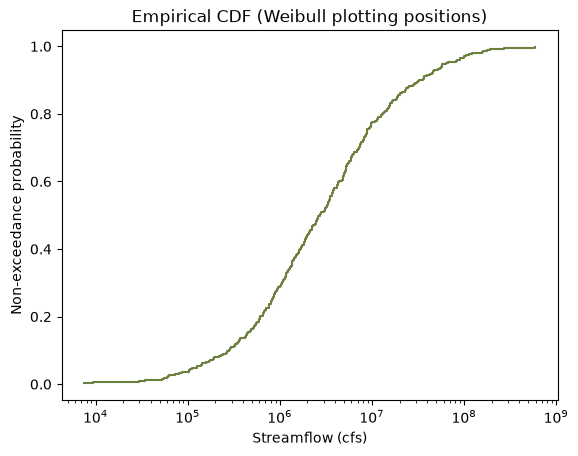

Weibull, n = 10: [0.090909 0.181818 0.272727 0.363636 0.454545 0.545455 0.636364 0.727273
 0.818182 0.909091]
Median (alpha = 0.3175), n = 10: [0.065847 0.162325 0.258804 0.355282 0.451761 0.548239 0.644718 0.741196
 0.837675 0.934153]


In [4]:
pp = ch.plotting_positions(len(streamflow))
plt.plot(np.sort(streamflow), pp, drawstyle="steps-post", color="#6b7f3f")
plt.xscale("log")
plt.xlabel("Streamflow (cfs)")
plt.ylabel("Non-exceedance probability")
plt.title("Empirical CDF (Weibull plotting positions)")
plt.show()

print("Weibull, n = 10:", np.round(ch.plotting_positions(10), 6))
print("Median (alpha = 0.3175), n = 10:",
      np.round(ch.plotting_positions(10, method="median"), 6))

## Correlation

The upstream section uses the Numerics `Correlation` class for three measures:
Pearson (linear association), Spearman (Pearson on ranks, so monotonic
association), and Kendall's $\tau_b$ (concordance, tie-adjusted). Like
`Statistics`, that class is internal to the port; numpy and pandas compute the
same coefficients, and the seeded data is identical. Kendall's $\tau_b$ comes
from `scipy.stats.kendalltau` in Python or `cor(method = "kendall")` in R; on
this data it also equals 1.

Two upstream quirks worth knowing. Reusing seed 321 for both the temperature and
the noise makes the noise an exactly linear function of temperature, so the
"noisy" sales data is perfectly linear and every coefficient is exactly 1. And
the outliers the upstream inserts are added after the data has been converted to
.NET, so they never reach the correlation calls. We reproduce the coefficients as
printed.

Pearson correlation:  1.0000
Spearman correlation: 1.0000


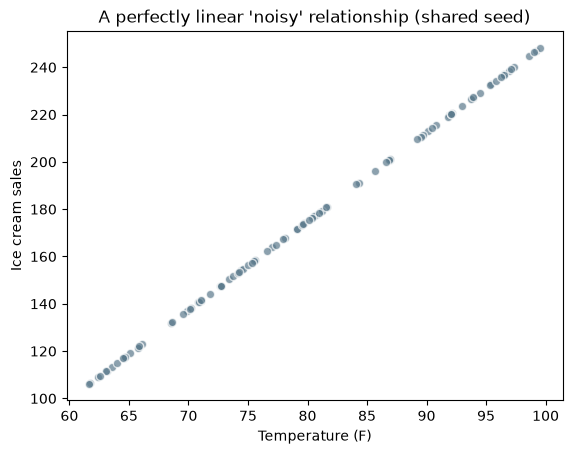

In [5]:
temperature = np.asarray(ch.Distribution("Uniform", [60, 100]).random(100, seed=321))
noise = np.asarray(ch.Distribution("Uniform", [0, 50]).random(100, seed=321))
sales = 2.5 * temperature - 50 + noise

pearson_r = np.corrcoef(temperature, sales)[0, 1]
spearman_r = np.corrcoef(pd.Series(temperature).rank(), pd.Series(sales).rank())[0, 1]
print(f"Pearson correlation:  {pearson_r:.4f}")
print(f"Spearman correlation: {spearman_r:.4f}")

plt.scatter(temperature, sales, color="#5b7a8c", alpha=0.7, edgecolors="white")
plt.xlabel("Temperature (F)")
plt.ylabel("Ice cream sales")
plt.title("A perfectly linear 'noisy' relationship (shared seed)")
plt.show()

## Not ported: hypothesis tests, Grubbs-Beck, Jenks

The upstream notebook's middle sections use classes this port does not expose:

- Hypothesis tests (one- and two-sample t, Mann-Whitney U, Kolmogorov-Smirnov):
  the Numerics `HypothesisTests` and `GoodnessOfFit` classes are internal to the
  core, and `scipy.stats` (or `t.test`, `wilcox.test`, and `ks.test` in R) covers
  the same ground.
- The single Grubbs-Beck outlier test is not public; only the Multiple
  Grubbs-Beck generalization below is, because that is the form Bulletin 17C uses.
- Jenks natural breaks: the `Numerics.MachineLearning` namespace is outside the
  scope of the port.

## Bootstrap resampling

The upstream notebook bootstraps the product moments of a Gamma fit through
`BootstrapAnalysis.ProductMoments`. The port wraps the same Numerics
`BootstrapAnalysis` engine behind one public function, `ch.bootstrap_analysis`,
which exposes the quantile-curve surface instead: fit a distribution to the data,
resample it `replications` times, re-estimate the parameters each time, and
return percentile confidence bands on the quantile curve. The Normal family is
currently the one wired to the bootstrap interface, so this recast bootstraps the
Normal(100, 15) sample the upstream notebook generates for its t-test control
group (seed 456; its mean, 96.881317, is printed upstream and asserted below).

In [6]:
sample = np.asarray(ch.Distribution("Normal", [100, 15]).random(50, seed=456))
probs = np.array([0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5,
                  0.6, 0.7, 0.8, 0.9, 0.95, 0.99])
boot = ch.bootstrap_analysis(sample, "Normal", probs,
                             replications=5000, seed=456, alpha=0.05)
lower = np.asarray(boot["lower_ci"])
upper = np.asarray(boot["upper_ci"])
mode = np.asarray(boot["mode_curve"])

print(f"Sample mean:              {sample.mean():.6f}")
print(f"Fitted Normal parameters: {np.round(boot['parameters'], 6)}")
curve = pd.DataFrame({"Non-exceedance": probs, "Quantile (MLE fit)": mode,
                      "95% lower": lower, "95% upper": upper})
print(curve.to_string(index=False))

Sample mean:              96.881317
Fitted Normal parameters: [96.880935 13.171142]
 Non-exceedance  Quantile (MLE fit)  95% lower  95% upper
           0.01           66.240276  59.482488  73.411757
           0.05           75.216334  69.858424  80.958322
           0.10           80.001437  75.296967  85.098189
           0.20           85.795822  81.695007  90.213022
           0.30           89.973981  86.092330  93.963681
           0.40           93.544064  89.852746  97.282840
           0.50           96.880935  93.196345 100.524630
           0.60          100.217806  96.421743 103.875593
           0.70          103.787889  99.682803 107.589205
           0.80          107.966048 103.475251 112.125387
           0.90          113.760433 108.464354 118.542027
           0.95          118.545536 112.566332 124.074600
           0.99          127.521594 120.219935 134.477131


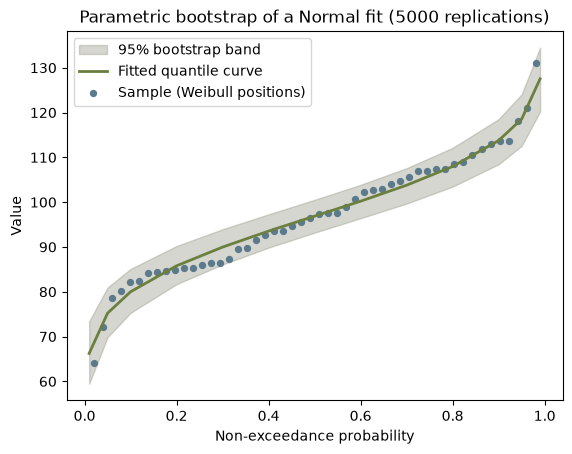

In [7]:
plt.fill_between(probs, lower, upper, color="#8c8c7a", alpha=0.35,
                 label="95% bootstrap band")
plt.plot(probs, mode, color="#6b7f3f", linewidth=2, label="Fitted quantile curve")
plt.scatter(ch.plotting_positions(len(sample)), np.sort(sample),
            color="#5b7a8c", s=18, label="Sample (Weibull positions)")
plt.xlabel("Non-exceedance probability")
plt.ylabel("Value")
plt.title("Parametric bootstrap of a Normal fit (5000 replications)")
plt.legend()
plt.show()

## Outlier detection: Multiple Grubbs-Beck

The classic Grubbs-Beck test flags outliers under a log-normality assumption
using a critical value that depends on sample size. The Multiple Grubbs-Beck test
(MGBT) generalizes it to detect several potentially influential low floods
(PILFs) at once, which matters in Bulletin 17C flood frequency analysis because
low outliers can distort the fitted Log-Pearson Type III curve and bias
upper-tail quantiles. `ch.mgbt_test` returns the number of low outliers detected.
Note that MGBT is a low-outlier screen only: the high value of 200 planted in
this sample is not flagged.

In [8]:
clean = np.asarray(ch.Distribution("Normal", [100, 10]).random(47, seed=789))
values = np.concatenate([clean, [35.0, 30.0, 200.0]])
n_low = ch.mgbt_test(values)

mgbt_summary = pd.DataFrame({
    "Metric": ["Sample size", "Mean", "Std Dev", "Low outliers detected (MGBT)"],
    "Value": [len(values), values.mean(), values.std(ddof=1), n_low],
})
print(mgbt_summary.to_string(index=False))

                      Metric     Value
                 Sample size 50.000000
                        Mean 98.159548
                     Std Dev 21.844798
Low outliers detected (MGBT)  2.000000


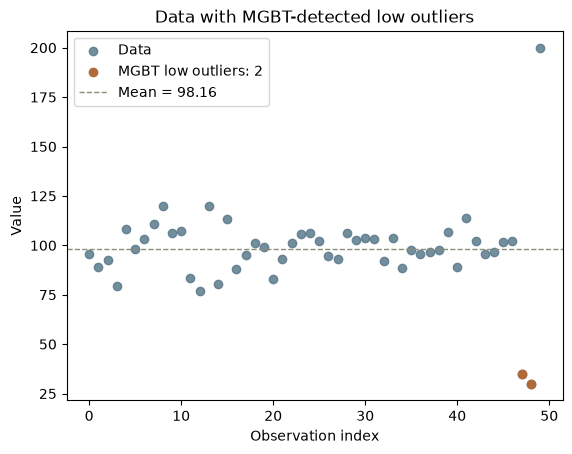

In [9]:
low_idx = np.argsort(values)[:n_low]
plt.scatter(np.arange(len(values)), values, color="#5b7a8c", alpha=0.85,
            label="Data")
plt.scatter(low_idx, values[low_idx], color="#b06a3b",
            label=f"MGBT low outliers: {n_low}")
plt.axhline(values.mean(), color="#8c8c7a", linestyle="--", linewidth=1,
            label=f"Mean = {values.mean():.2f}")
plt.xlabel("Observation index")
plt.ylabel("Value")
plt.title("Data with MGBT-detected low outliers")
plt.legend()
plt.show()

## Data transformations: Box-Cox and Yeo-Johnson

Both transformations reshape a skewed variable toward normality. Box-Cox requires
strictly positive data and finds a power $\lambda$ that stabilizes variance and
reduces skew; Yeo-Johnson extends the idea to zero and negative values. The port
fits $\lambda$ by maximum likelihood over $[-5, 5]$ (`box_cox_lambda`,
`yeo_johnson_lambda`) and provides the forward and inverse transforms.

One honest floating-point note: the fitted exponent comes from a numerical search
(Brent), and its trailing digits depend on platform and compiler, so Python and R
agree to about seven decimals here rather than bit-exactly. The reproduction
check therefore asserts the precision the upstream notebook prints.

In [10]:
bc_data = np.asarray(ch.Distribution("LogNormal", [1, 0.75]).random(500, seed=789))
lambda_bc = ch.box_cox_lambda(bc_data)
bc_t = np.asarray(ch.box_cox(bc_data, lambda_bc))
bc_err = np.max(np.abs(bc_data - np.asarray(ch.box_cox_inverse(bc_t, lambda_bc))))

yj_data = (np.asarray(ch.Distribution("Normal", [0, 2]).random(500, seed=456))
           + np.asarray(ch.Distribution("Exponential", [1, 1.5]).random(500, seed=456)))
lambda_yj = ch.yeo_johnson_lambda(yj_data)
yj_t = np.asarray(ch.yeo_johnson(yj_data, lambda_yj))
yj_err = np.max(np.abs(yj_data - np.asarray(ch.yeo_johnson_inverse(yj_t, lambda_yj))))

# Std uses the population formula (ddof=0) to match the upstream np.std table.
rows = [("Box-Cox (original)", bc_data, lambda_bc, bc_err),
        ("Box-Cox (transformed)", bc_t, lambda_bc, bc_err),
        ("Yeo-Johnson (original)", yj_data, lambda_yj, yj_err),
        ("Yeo-Johnson (transformed)", yj_t, lambda_yj, yj_err)]
transform_summary = pd.DataFrame(
    [{"Transform": name, "Mean": x.mean(), "Std": x.std(), "Min": x.min(),
      "Max": x.max(), "Lambda": lam, "Round-trip error": err}
     for name, x, lam, err in rows])
print(transform_summary.to_string(index=False))

                Transform      Mean        Std       Min         Max   Lambda  Round-trip error
       Box-Cox (original) 38.944335 132.921321  0.077764 1942.229448 0.020475      4.320100e-12
    Box-Cox (transformed)  2.380719   1.721469 -2.488445    8.190029 0.020475      4.320100e-12
   Yeo-Johnson (original)  2.527081   3.536851 -4.984451   18.998849 0.709817      3.552714e-15
Yeo-Johnson (transformed)  1.645339   2.560638 -7.020563   10.403344 0.709817      3.552714e-15


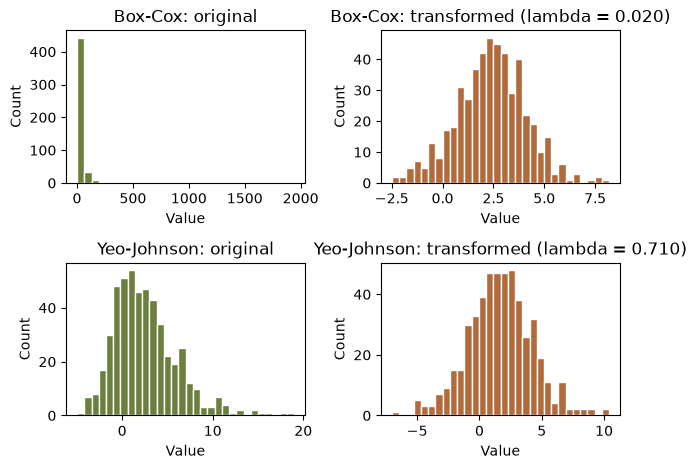

In [11]:
fig, axes = plt.subplots(2, 2)
axes[0, 0].hist(bc_data, bins=30, color="#6b7f3f", edgecolor="white")
axes[0, 0].set_title("Box-Cox: original")
axes[0, 1].hist(bc_t, bins=30, color="#b06a3b", edgecolor="white")
axes[0, 1].set_title(f"Box-Cox: transformed (lambda = {lambda_bc:.3f})")
axes[1, 0].hist(yj_data, bins=30, color="#6b7f3f", edgecolor="white")
axes[1, 0].set_title("Yeo-Johnson: original")
axes[1, 1].hist(yj_t, bins=30, color="#b06a3b", edgecolor="white")
axes[1, 1].set_title(f"Yeo-Johnson: transformed (lambda = {lambda_yj:.3f})")
for ax in axes.flat:
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")
fig.tight_layout()
plt.show()

## Key takeaways

1. Descriptive statistics and correlation need no special library; the port
   leaves them to numpy, pandas, and base R.
2. Bootstrap for uncertainty when you do not want strong assumptions; the port's
   surface is confidence bands on the quantile curve.
3. Screen for low outliers with MGBT before fitting a flood frequency curve, and
   investigate before removing anything.
4. Normalize skewed positive data with Box-Cox; reach for Yeo-Johnson when zeros
   or negatives appear.

## Reproduction check

Values printed by the upstream notebook (run against the real C# library),
compared with this port. "exact" means the value matches every digit the
upstream notebook prints; the two fitted exponents are asserted at that printed
precision because a numerical search sets their trailing digits (see the
transforms section). "internal" rows have no upstream number, so they assert
internal consistency plus cross-language identity against the R twin.

| Quantity | Upstream C# | This port | Status |
|----------|------------:|----------:|--------|
| Streamflow mean (`LogNormal(6.5,0.8)`, n=365, seed 42) | 1.397387e+07 | `s.mean()` | exact |
| Streamflow std dev | 4.195469e+07 | `s.std()` | exact |
| Streamflow skewness $G_1$ | 8.697790 | `s.skew()` | exact |
| Streamflow excess kurtosis | 103.8059 | `s.kurt()` | exact |
| Streamflow 95th percentile | 5.803155e+07 | `np.percentile` | exact |
| Pearson / Spearman correlation | 1.0000 | `np.corrcoef` | exact |
| Control sample mean (`Normal(100,15)`, n=50, seed 456) | 96.881317 | `sample.mean()` | exact |
| MGBT low outliers | 2 | `ch.mgbt_test` | exact |
| MGBT sample mean / std dev | 98.159548 / 21.844798 | numpy | exact |
| Box-Cox lambda | 0.020475 | `ch.box_cox_lambda` | exact |
| Box-Cox transformed mean | 2.380719 | `bc_t.mean()` | exact |
| Yeo-Johnson lambda | 0.709817 | `ch.yeo_johnson_lambda` | exact |
| Yeo-Johnson transformed mean | 1.645339 | `yj_t.mean()` | exact |
| Transform round trips | (not printed) | max abs error < 1e-9 | internal |
| Bootstrap quantile bands | (no upstream analogue) | ordering + literals | internal |
| Plotting positions | (not in upstream 09) | closed form | internal |

The cell below fails the notebook if any value drifts.

In [12]:
# Upstream: 09_statistics.ipynb, cell 4 output (descriptive summary table).
assert abs(s.mean() / 1.397387e7 - 1) < 1e-6
assert abs(s.std() / 4.195469e7 - 1) < 1e-6
assert abs(s.skew() - 8.697790) < 5e-7
assert abs(s.kurt() / 103.8059 - 1) < 1e-6
assert abs(np.percentile(streamflow, 95) / 5.803155e7 - 1) < 1e-6

# Upstream: cell 6 output (all three coefficients print 1.0000).
assert pearson_r > 1 - 1e-12
assert spearman_r > 1 - 1e-12

# Upstream: cell 8 output (t-test control group mean, reused for the bootstrap).
assert abs(sample.mean() - 96.881317) < 5e-7

# Upstream: cell 17 output (Multiple Grubbs-Beck summary).
assert n_low == 2
assert abs(values.mean() - 98.159548) < 5e-7
assert abs(values.std(ddof=1) - 21.844798) < 5e-7

# Upstream: cell 21 output (transformation summary table).
assert abs(lambda_bc - 0.020475) < 5e-7
assert abs(bc_t.mean() - 2.380719) < 5e-7
assert abs(lambda_yj - 0.709817) < 5e-7
assert abs(yj_t.mean() - 1.645339) < 5e-7

# Internal consistency: transforms invert, plotting positions match closed form.
assert bc_err < 1e-9 and yj_err < 1e-9
assert np.allclose(ch.plotting_positions(10), np.arange(1, 11) / 11,
                   rtol=0, atol=1e-15)

# Internal consistency: bootstrap bands bracket the fitted curve, and the fitted
# median of a Normal is its mean parameter.
i50 = 6  # probs[6] == 0.5
assert np.all(lower < mode) and np.all(mode < upper)
assert mode[i50] == boot["parameters"][0]

# Cross-language identity: the R twin asserts these same seeded literals.
assert streamflow[0] == 1754357.4518502082
assert boot["parameters"][0] == 96.88093513274926
assert lower[i50] == 93.19634521338513
assert upper[i50] == 100.52462982500435
assert values.mean() == 98.15954794981819
assert ch.plotting_positions(10, method="median")[0] == 0.06584659913169319
print("All reproduction checks passed.")

All reproduction checks passed.
